# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [23]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.4097
      Test MAE: 4.98 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.5658
      Test MAE: 11.48 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  0.4799
      Test MAE: 18.28 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.9807
      Test MAE: 2.98 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.9533
      Test MAE: 16.04 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                 feature  coefficient
     speed_fly_deviation     2.434494
condition_immunity_count     2.356248
  speed_ground_deviation     2.280135
     total_ability_count    -1.654340
      inflicts_petrified    -1.512433
      inflicts_paralyzed    -1.119809
     vulnerability_count    -0.944148
       spellcaster_level    -0.886919
  save_proficiency_count     0.787243
             speed_climb    -0.731597

CR2 Top Features by Coefficient:
                    feature  coefficient
          spellcaster_level    -5.427423
     save_proficiency_count     5.154580
    skill_proficiency_count    -3.644197
        vulnerability_count     3.563618
                speed_climb    -3.278089
           inflicts_charmed    -3.092256
                 speed_swim     3.061025
                trait_count     2.596074
has_magic_resistance_scaled    -2.564761
               speed_burrow    -2.461672

CR3 Top Features by Coefficient:
                 feature  coe

## Investigate Specific Creatures

In [11]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# investigate_creature('Adult Red Dragon', df, contributions_df)
# investigate_creature('Tarrasque', df, contributions_df)
investigate_creature('Goblin', df, contributions_df)

  GOBLIN (CR 0.25)

Actual HP:               7
Predicted HP:            9
Error:                   2  (  35.3%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 0.25):                                20

PHASE 1.5: RESISTANCES & IMMUNITIES
  No resistances or immunities
  HP after Phase 1.5:                                    20

PHASE 2: COMBAT STATS
  AC Contribution                                     -6
  Attack Bonus Contribution                           -2
  DPR Contribution                                    -0
  -----------------------------------------------------
  Phase 2 Total:                                         -8
  HP after Phase 2:                                      11

PHASE 3: INDIVIDUAL FEATURES
  Feature: has_legendary_resistance_scaled     value:    N/A  hp impact:     -0
  Feature: has_magic_resistance_scaled         value:    N/A  hp impact:     -0
  Feature: has_regeneration_scaled   

In [19]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [15]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
      Name    CR  Actual_HP  Predicted_HP     Error
   Cultist 0.125          9      8.999988  0.000012
   Acolyte 0.250          9      8.999980  0.000020
Cockatrice 0.500         27     27.000028 -0.000028
  Axe Beak 0.250         19     18.876112  0.123888
  Commoner 0.000          4      3.855074  0.144926
      Wolf 0.250         11     10.807677  0.192323
  Scorpion 0.000          1      1.239695 -0.239695
    Stirge 0.125          2      1.716339  0.283661
      Pony 0.125         11     11.318422 -0.318422
     Camel 0.125         15     15.376112 -0.376112

CR < 1 - Worst 10 Predictions:
           Name   CR  Actual_HP  Predicted_HP      Error
     Black Bear 0.50         19     29.783885 -10.783885
        Octopus 0.00          3     -8.436675  11.436675
     Giant Wasp 0.50         13     25.056748 -12.056748
      Crocodile 0.50         19     31.242564 -12.242564
         Dretch 0.25         18      5.221305  12.778695
           Drow 0.25   


CR 11-16 - Best 10 Predictions:
       Name   CR  Actual_HP  Predicted_HP     Error
  Ice Devil 14.0        180    180.000047 -0.000047
    Vampire 13.0        144    143.999931  0.000069
    Erinyes 12.0        153    152.999928  0.000072
Purple Worm 15.0        247    247.079736 -0.079736
   Planetar 16.0        200    200.096240 -0.096240
   Archmage 12.0         99     98.702829  0.297171
   Remorhaz 11.0        195    194.460007  0.539993
 Iron Golem 16.0        210    210.566536 -0.566536
 Nalfeshnee 13.0        184    184.615445 -0.615445
   Rakshasa 13.0        110    110.619552 -0.619552

CR 11-16 - Worst 10 Predictions:
               Name   CR  Actual_HP  Predicted_HP      Error
            Efreeti 11.0        200    198.339817   1.660183
Adult Bronze Dragon 15.0        212    213.744798  -1.744798
           Marilith 16.0        189    187.005203   1.994797
       Horned Devil 11.0        178    180.197965  -2.197965
  Adult Blue Dragon 16.0        225    228.047097  -3.04


📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


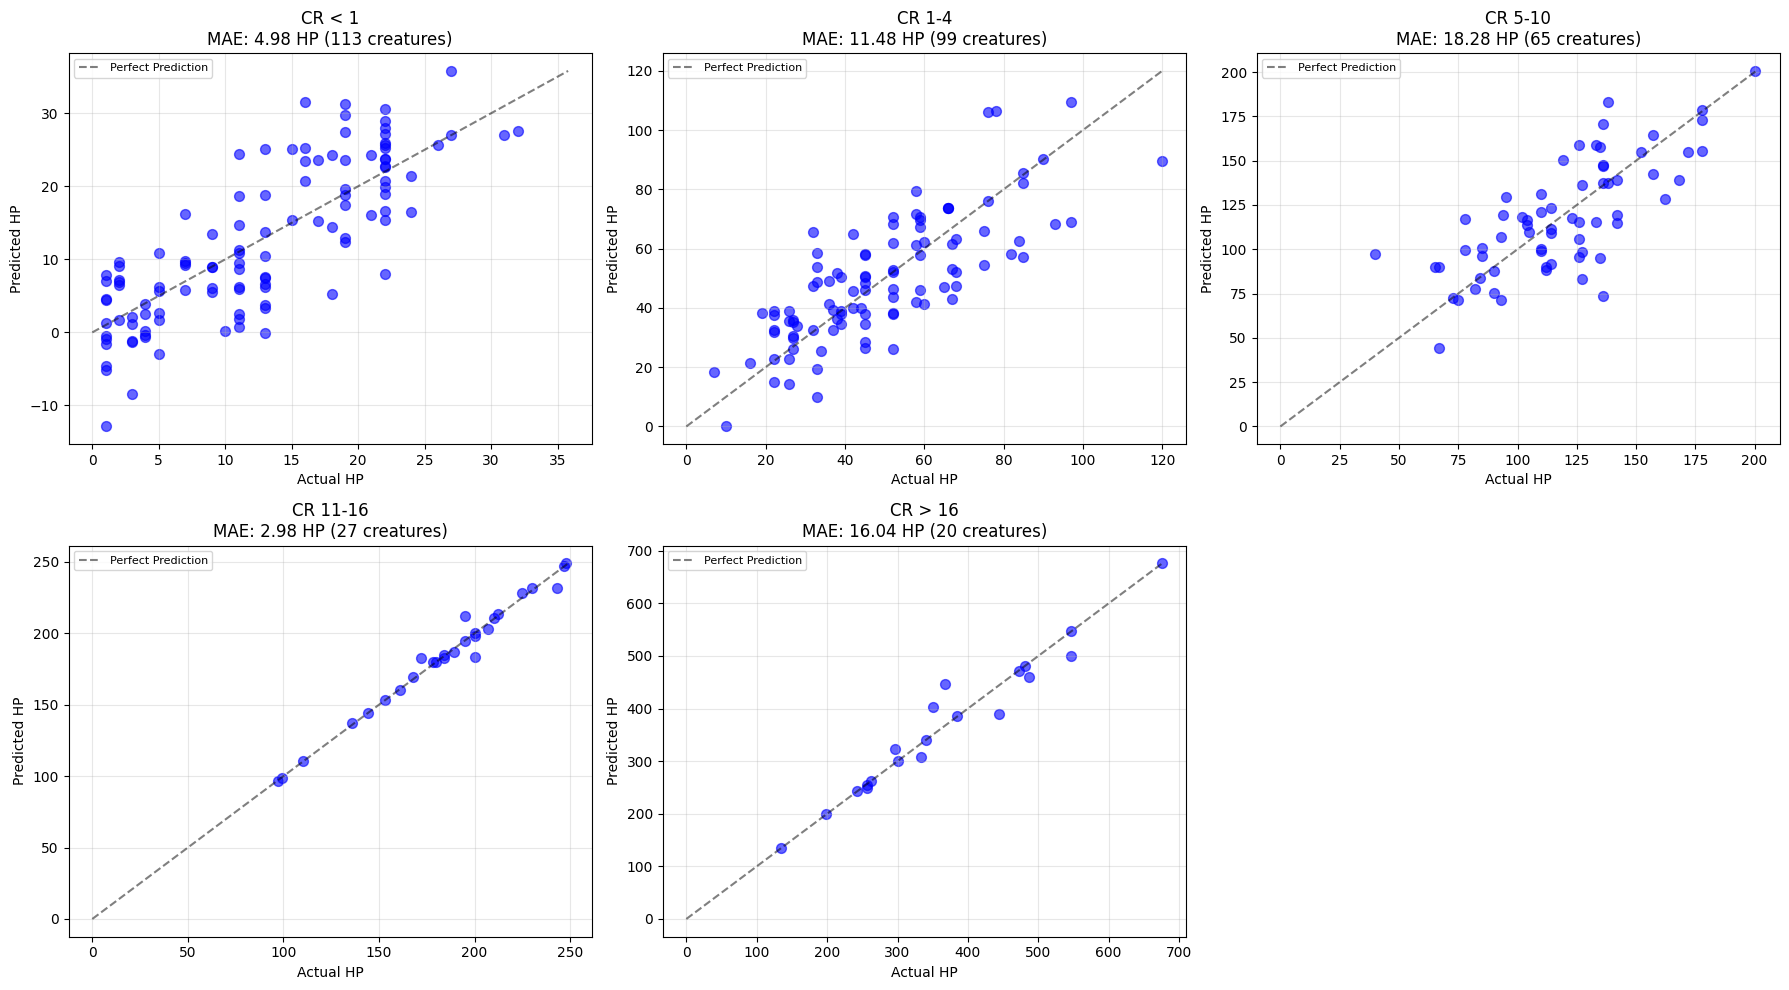

In [17]:
plot_performance_scatter(analysis_dfs)


📊 VISUALIZATION: Error Distribution (5 CR Buckets)


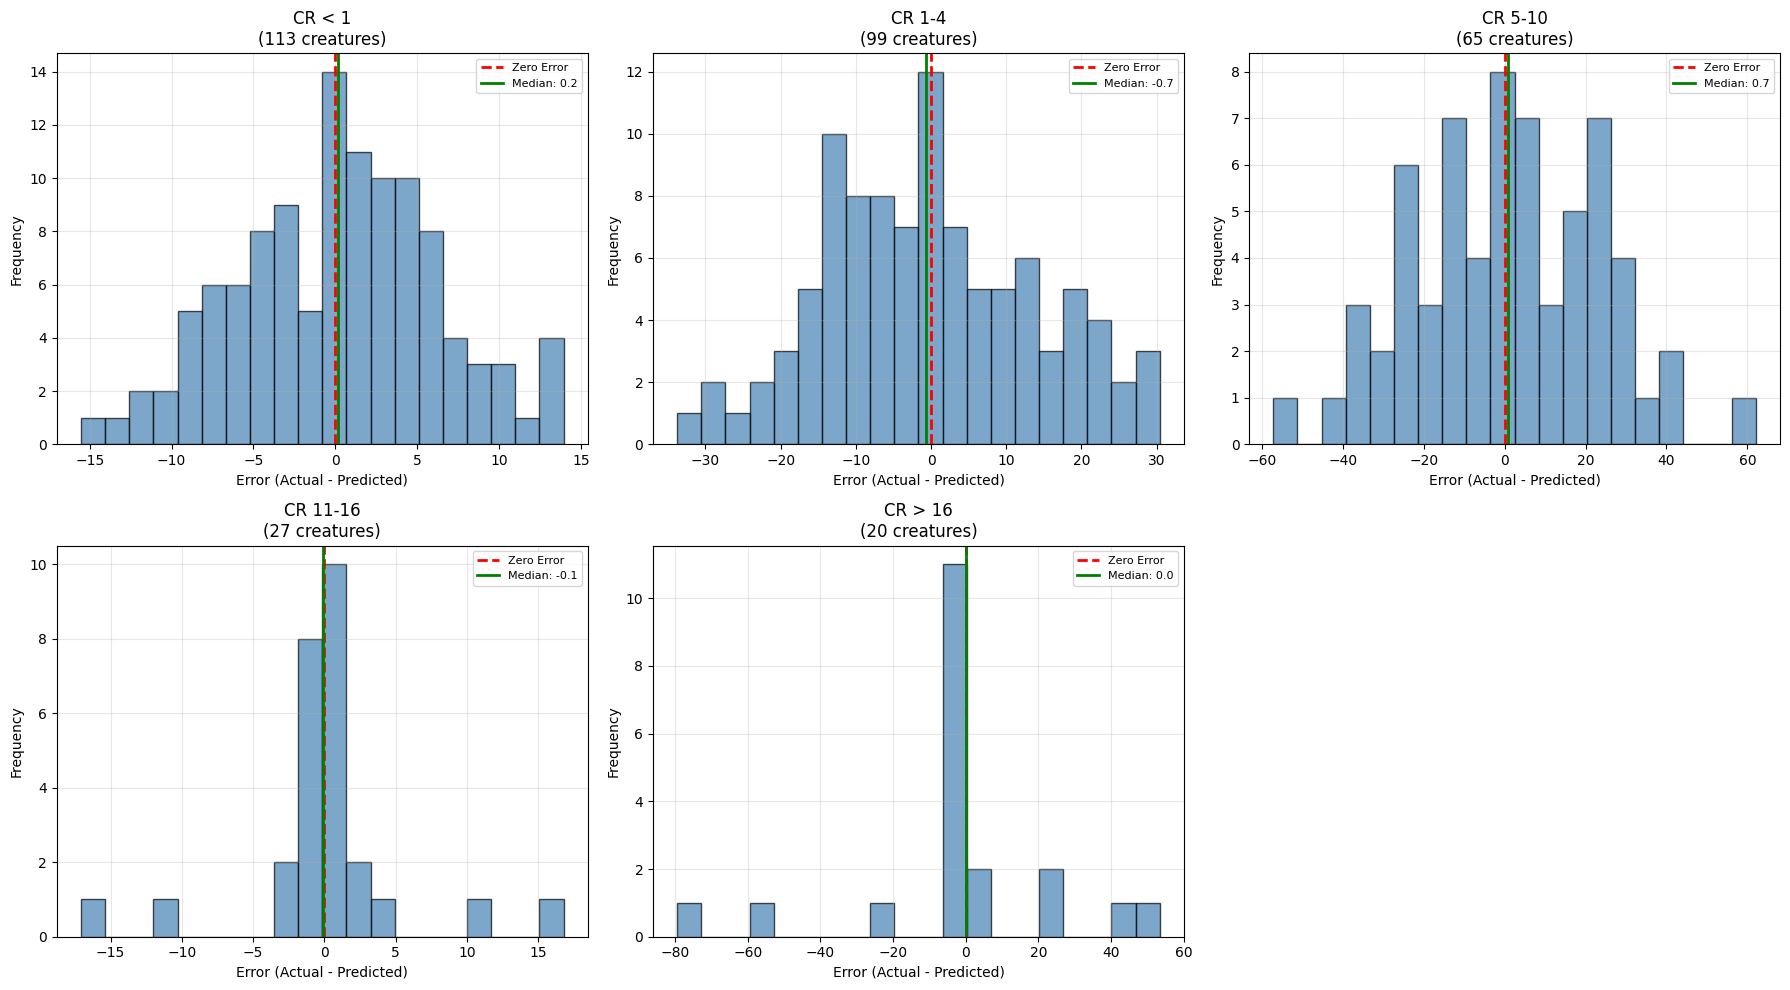

In [18]:
plot_error_hist(analysis_dfs)